# Machine Learning - Customer Churn Prediction

The objective of this notebook is to develop and evaluate machine learning models capable of predicting customer churn in a telecommunications company.

Using the cleaned Telco Customer Churn dataset, several classification algorithms will be trained and compared to identify the most effective model for predicting customer attrition.

This notebook follows the machine learning workflow:

1. Data Loading
2. Data Preparation
3. Feature Engineering
4. Data Preprocessing
5. Model Training
6. Model Evaluation
7. Model Comparison
8. Business Conclusions


## Problem Definition

The objective of this phase is to build a machine learning model capable of predicting whether a customer is likely to churn based on demographic information, subscribed services, contract details, and billing information.

This is a **supervised binary classification problem**, where the target variable has two possible classes:

- **0** → Customer stays (No Churn)
- **1** → Customer leaves (Churn)

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [2]:
## Load the Dataset:the cleaned dataset generated during the data cleaning phase is loaded for machine learning.

df = pd.read_csv("Clean Data/telco_clean.csv")

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChargeLevel,TenureGroup,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low,New,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,Medium,Mid,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium,New,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium,Old,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,High,New,1


In [4]:
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChargeLevel,TenureGroup,ChurnFlag
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,No,High,Mid,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,High,Old,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Low,New,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,High,New,1
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,High,Old,0


## Dataset Inspection

Before training machine learning models, it is important to inspect the cleaned dataset to verify its structure, data types, and overall quality.

The objective of this step is to ensure that the dataset is ready for preprocessing and model training.

In [5]:
df.shape

(7043, 24)

# Dataset Overview

The cleaned Telco Customer Churn dataset contains 7,043 customer records and 24 features.

The dataset includes:

- Customer demographic information
- Subscribed services
- Contract details
- Billing information
- Customer churn indicator

The target variable is `ChurnFlag`, where:

- 0 → Customer stays
- 1 → Customer churns

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'ChargeLevel', 'TenureGroup', 'ChurnFlag'],
      dtype='object')

# Feature Selection

Machine learning algorithms cannot use all available information directly.Before training the models, we need to select the relevant features and define the target variable.
In this step, we prepare the dataset for the machine learning phase by:
- Removing irrelevant variables
- Avoiding redundant information
- Preventing data leakage
- Separating input features (X) from the target variable (y)

# Removed features:

-customerID: This column is only a unique identifier for each customer.It does not contain any predictive information about customer churn.

-Churn: This variable contains the same information as the target variable `ChurnFlag`:
- No → 0
- Yes → 1
Keeping this column would introduce data leakage because the model would directly access the answer.

-ChargeLevel: This feature was created during the exploratory data analysis from `MonthlyCharges`.
It is useful for business segmentation, but for machine learning we keep the original numerical variable (`MonthlyCharges`) and allow the model to learn the relationship automatically.

-TenureGroup:
This feature was created from the original variable `tenure`.
For the machine learning phase, we keep the original customer tenure information and remove this engineered category.

After this step, the dataset will contain only the variables used for model training.

In [7]:
df_ml = df.drop(
    ["customerID", "Churn", "ChargeLevel", "TenureGroup"],
    axis=1
)

# Define Features and Target Variable

In supervised machine learning, the dataset is divided into:

- Features (X): input variables used by the model to learn customer behavior.
- Target (y): the variable that the model tries to predict.

For this project:

- The target variable is `ChurnFlag`
    - 0 → Customer stays
    - 1 → Customer churns

All remaining variables will be used as predictive features.

In [8]:
X = df_ml.drop("ChurnFlag", axis=1)

In [9]:
y = df_ml["ChurnFlag"]

In [10]:
X.shape

(7043, 19)

In [11]:
y.value_counts()

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

In [12]:
y.value_counts(normalize=True) * 100

ChurnFlag
0    73.463013
1    26.536987
Name: proportion, dtype: float64

# Target Variable Distribution

The target variable `ChurnFlag` represents customer churn:

- 0 → Customer stays
- 1 → Customer churns

The distribution is:

- Non-churn customers: 5174 (73.5%)
- Churn customers: 1869 (26.5%)

The dataset is moderately imbalanced because the two classes are not equally represented.

This imbalance should be considered during model evaluation, as accuracy alone may not be sufficient. Metrics such as precision, recall, F1-score, and ROC-AUC will also be analyzed.

# Train-Test Split

Before training a machine learning model, the dataset is divided into two parts:

- Training set: used by the model to learn patterns from the data.
- Testing set: used to evaluate the model performance on unseen data.

In this project, we split the data into:

- 80% for training
- 20% for testing

The `stratify` parameter is used to preserve the original distribution of the target variable (`ChurnFlag`) in both datasets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

In [14]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [14]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

ChurnFlag
0    0.734647
1    0.265353
Name: proportion, dtype: float64
ChurnFlag
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Data Preprocessing

Machine learning algorithms require numerical input data.

Numerical features are standardized using StandardScaler to bring variables to the same scale.

Categorical features are transformed using OneHotEncoder to convert text categories into numerical binary variables while avoiding artificial ordering between categories.

In [15]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [16]:
numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [17]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [18]:
X.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [19]:
y.dtypes

dtype('int64')

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

 # Feature Preprocessing

A ColumnTransformer is used to apply different preprocessing techniques depending on feature types.

- Numerical features are standardized using StandardScaler to ensure comparable scales.
- Categorical features are transformed using OneHotEncoder to convert categories into numerical representations.

This preprocessing step prepares the dataset for machine learning algorithms.

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Machine Learning Pipeline

A machine learning pipeline is created to combine data preprocessing and model training into a single workflow.

The pipeline includes:

1. Data preprocessing:
   - StandardScaler for numerical variables
   - OneHotEncoder for categorical variables

2. Classification model:
   - Logistic Regression for binary churn prediction

This approach ensures that the same preprocessing steps are applied consistently during training and prediction.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [24]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Model Training
The Logistic Regression model is trained using the training dataset.
The pipeline automatically applies preprocessing steps before fitting the classifier.
The model learns patterns from customer features to predict churn probability.

In [25]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred = lr_pipeline.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


# Model Evaluation - Accuracy

Accuracy measures the proportion of correctly classified customers among all test samples.
The Logistic Regression model achieved an accuracy of approximately 80.5%, meaning that the model correctly predicts customer churn status for about 8 out of 10 customers.

However, accuracy alone is not sufficient because the dataset is slightly imbalanced (more non-churn customers than churn customers). Therefore, additional metrics such as precision, recall, F1-score and ROC-AUC will be analyzed.

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# Classification Report Analysis

The classification report provides a detailed evaluation of the Logistic Regression model.

- The model performs well in identifying non-churn customers (class 0), with a recall of 89%.
- For churn customers (class 1), the model achieves a precision of 66% and a recall of 56%.

Although the overall accuracy is around 80.5%, churn detection remains challenging because missing potential churners can have a direct business impact.

Further improvements could focus on increasing recall for the churn class using techniques such as:
- class weighting
- threshold tuning
- more advanced classification models

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[926, 109],
       [165, 209]])

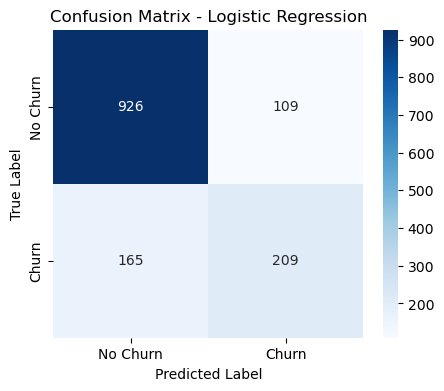

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# Interpretation confusion matrix

The confusion matrix shows that the model correctly classified **926** non-churn customers and **209** churn customers.
However, **165** churn customers were incorrectly predicted as non-churn (False Negatives). These customers represent missed retention opportunities.
Reducing False Negatives would improve the business value of the model.

# ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between churn and non-churn customers.

The Area Under the Curve (AUC) summarizes this performance:
- 0.5 = random classifier
- 1.0 = perfect classifier

A higher AUC indicates better discrimination capability.

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr_pipeline.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC :", auc)


ROC-AUC : 0.8421349040274871


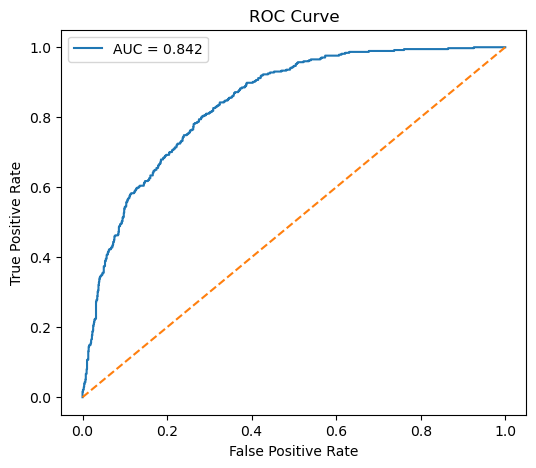

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ROC Curve Interpretation

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds.

The Logistic Regression model achieved a **ROC-AUC score of 0.842**, indicating a good ability to distinguish between churn and non-churn customers.

The ROC curve remains well above the random classifier baseline (diagonal line 0.5), confirming that the model has learned meaningful patterns from the customer data.

Although the current decision threshold is 0.5, the ROC curve suggests that threshold tuning could further improve churn detection by increasing recall while controlling false positives.

# Conclusion

Logistic Regression provides a solid baseline model for customer churn prediction.
The model achieved:
- Good overall accuracy (80.5%)
- Good discrimination capability (ROC-AUC = 0.842)
However, the recall for churn customers remains moderate (56%), meaning that some customers likely to churn are still missed.
To improve predictive performance, more advanced machine learning algorithms will be evaluated next including Decision Tree, Random Forest, and XGBoost.

# Model 2: Decision Tree

After establishing a Logistic Regression baseline, a Decision Tree classifier will be trained and evaluated.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between variables without requiring a linear decision boundary.Decision Tree is  capable of learning complex decision rules by recursively splitting the data.
The same preprocessing pipeline and evaluation metrics will be used to ensure a fair comparison between models.

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [36]:
dt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
y_pred_dt = dt_pipeline.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)

Accuracy : 0.7210787792760823


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1035
           1       0.48      0.49      0.48       374

    accuracy                           0.72      1409
   macro avg       0.64      0.65      0.65      1409
weighted avg       0.72      0.72      0.72      1409



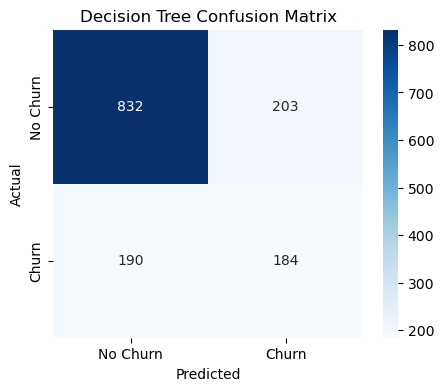

In [39]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
y_prob_dt = dt_pipeline.predict_proba(X_test)[:,1]

auc_dt = roc_auc_score(y_test, y_prob_dt)

print("ROC-AUC :", auc_dt)

ROC-AUC : 0.6476762510010592


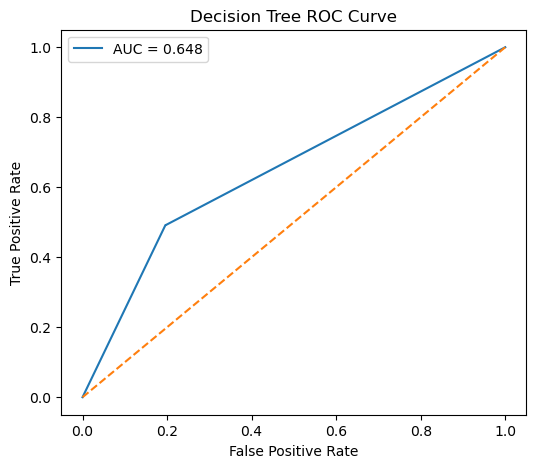

In [41]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,5))

plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.3f}")

plt.plot([0,1],[0,1],"--")

plt.title("Decision Tree ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Model 3: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [44]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
y_pred_rf = rf_pipeline.predict(X_test)

In [48]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)

Accuracy : 0.7863733144073811


In [49]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



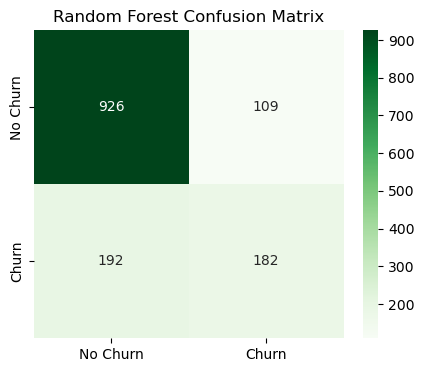

In [50]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [51]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC :", auc_rf)

ROC-AUC : 0.8185099072567104


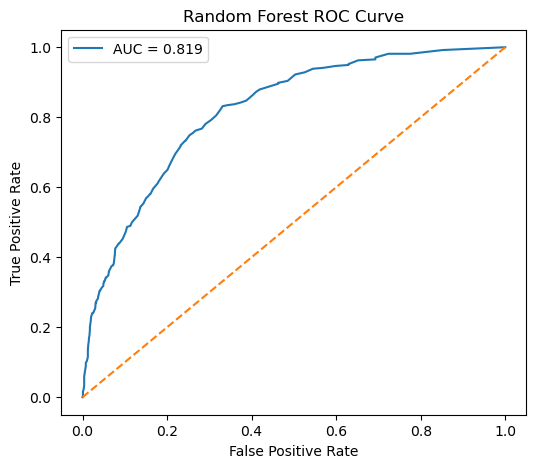

In [52]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}")

plt.plot([0,1],[0,1],"--")

plt.title("Random Forest ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Model 4: XGBoost

XGBoost (Extreme Gradient Boosting) is a boosting algorithm that sequentially builds decision trees to minimize prediction errors.

It is widely recognized as one of the best-performing algorithms for structured (tabular) datasets.

In [53]:
from xgboost import XGBClassifier


In [54]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"# Evaluation metric used during training for binary classification
    ))
])

In [55]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [57]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("Accuracy :", accuracy_xgb)

Accuracy : 0.7764371894960965


In [58]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



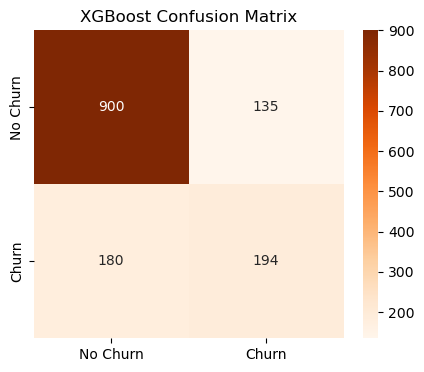

In [59]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [61]:
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC :", auc_xgb)

ROC-AUC : 0.820461649745537


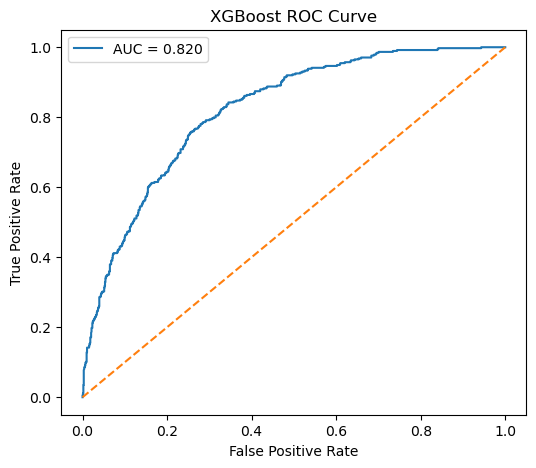

In [62]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))

plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {auc_xgb:.3f}")

plt.plot([0,1],[0,1],"--")

plt.title("XGBoost ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [64]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

def evaluate_model(model_name, y_true, y_pred, y_prob):

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [65]:
results_lr = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)

In [66]:
results_dt = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)

In [67]:
results_rf = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

In [68]:
results_xgb = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

In [69]:
results = pd.DataFrame([
    results_lr,
    results_dt,
    results_rf,
    results_xgb
])
results.style.format({
    "Accuracy":"{:.3f}",
    "Precision":"{:.3f}",
    "Recall":"{:.3f}",
    "F1-score":"{:.3f}",
    "ROC-AUC":"{:.3f}"
})
results = results.sort_values(
    by="ROC-AUC",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135,926,109,165,209
3,XGBoost,0.776437,0.589666,0.518717,0.551920,0.820462,900,135,180,194
2,Random Forest,0.786373,0.625430,0.486631,0.547368,0.818510,926,109,192,182
1,Decision Tree,0.721079,0.475452,0.491979,0.483574,0.647676,832,203,190,184


# Interprétation

The baseline evaluation shows that Logistic Regression achieved the best overall performance across all evaluation metrics.
However, the Recall remains relatively low (56%), meaning that nearly half of the customers who actually churn are still not detected.
Since the main business objective is customer retention, maximizing churn detection is more important than simply maximizing overall accuracy.
Therefore, the next step focuses on improving the models through hyperparameter tuning and threshold optimization.

# Hyperparameter Tuning

Rather than selecting the best baseline model immediately, the objective is to improve each model by optimizing its hyperparameters.
The goal is to increase the model's ability to identify customers who are likely to churn while maintaining good overall predictive performance.

# Business Objective

From a business perspective, failing to identify a customer who is about to churn (False Negative) is generally more costly than incorrectly flagging a loyal customer (False Positive). For this reason, improving Recall becomes a priority in this project. Detecting more potential churners enables the company to launch targeted retention campaigns before customers leave.